01. Exploratory Data Analysis (EDA) & Data Preparation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Импортируем наши функции
import sys
sys.path.append('../src')
from preprocessing import preprocess_pipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

### 1. Загрузка данных и проверка на чистоту
В описании датасета заявляено, что он очищен и готов к ML. Убедимся в этом.

In [5]:
df_raw = pd.read_csv('../data/raw/sleep_health_dataset.csv')
print(f"Размер исходного датасета: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов.")

# Проверка на пропуски 
missing_values = df_raw.isnull().sum().sum()
print(f"Общее количество пропущенных значений: {missing_values}")

# Проверка на дубликаты
duplicates = df_raw.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates}")

if missing_values == 0:
    print("-> Датасет абсолютно чистый, удаление пропусков не требуется.")


Размер исходного датасета: 100000 строк, 32 столбцов.
Общее количество пропущенных значений: 0
Количество полных дубликатов: 0
-> Датасет абсолютно чистый, удаление пропусков не требуется.


### 2. Обработка через Pipeline

Так как пропусков нет, в  `preprocess_pipeline` удалим только параллельные таргеты (`cognitive_performance_score` и `felt_rested`), чтобы избежать Data Leakage, так в задаче будем работать только с `sleep_disorder_risk`.

In [6]:
df_processed = preprocess_pipeline(df_raw)
print(f"Размер после удаления лишних таргетов: {df_processed.shape}")
display(df_processed.head())

Размер после удаления лишних таргетов: (100000, 30)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,sleep_disorder_risk
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,Healthy
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,Healthy
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,Severe
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,Healthy
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,Mild


### 3. Анализ целевой переменной

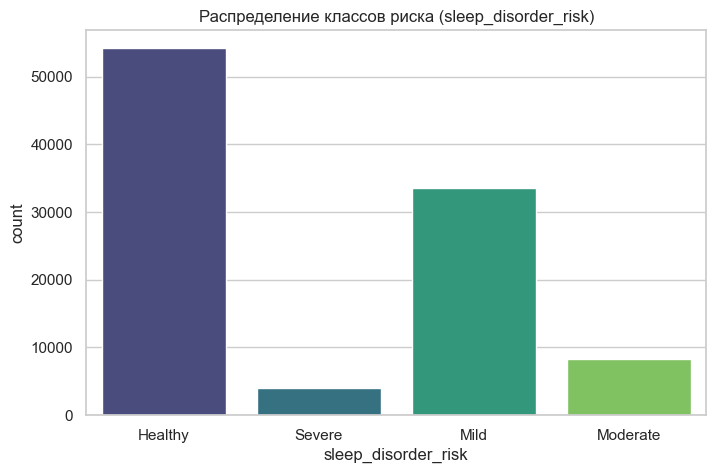

In [15]:
target_col = 'sleep_disorder_risk'

plt.figure(figsize=(8, 5))
# sns.countplot(data=df_processed, x=target_col, palette='viridis')
sns.countplot(data=df_processed, x=target_col, palette='viridis', hue=target_col, legend=False)
plt.title('Распределение классов риска (sleep_disorder_risk)')
plt.show()

 **Выбор метрики:** 
Распределение классов риска неравномерное, поэтому обычной метрики `Accuracy` будет недостаточно. Так как проект решает задачу мультиклассовой классификации, основной метрикой будет **F1-macro**.

### 4. Визуализация зависимостей

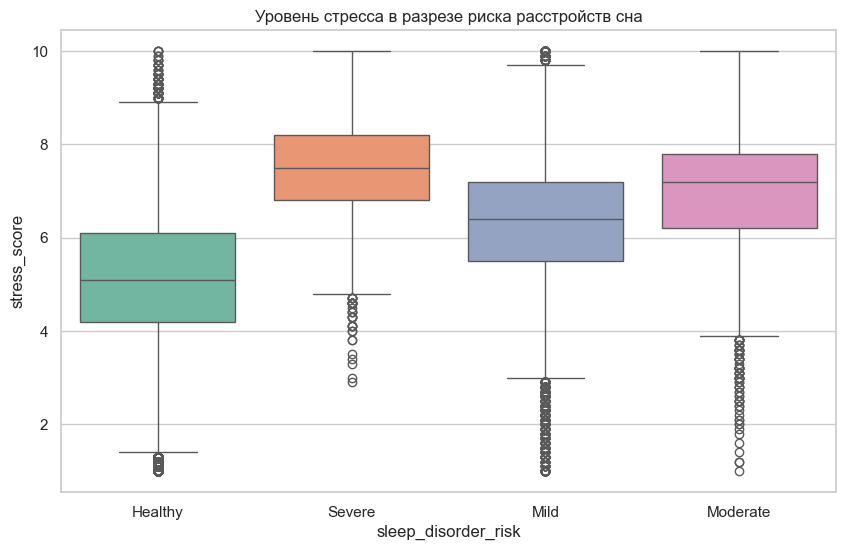

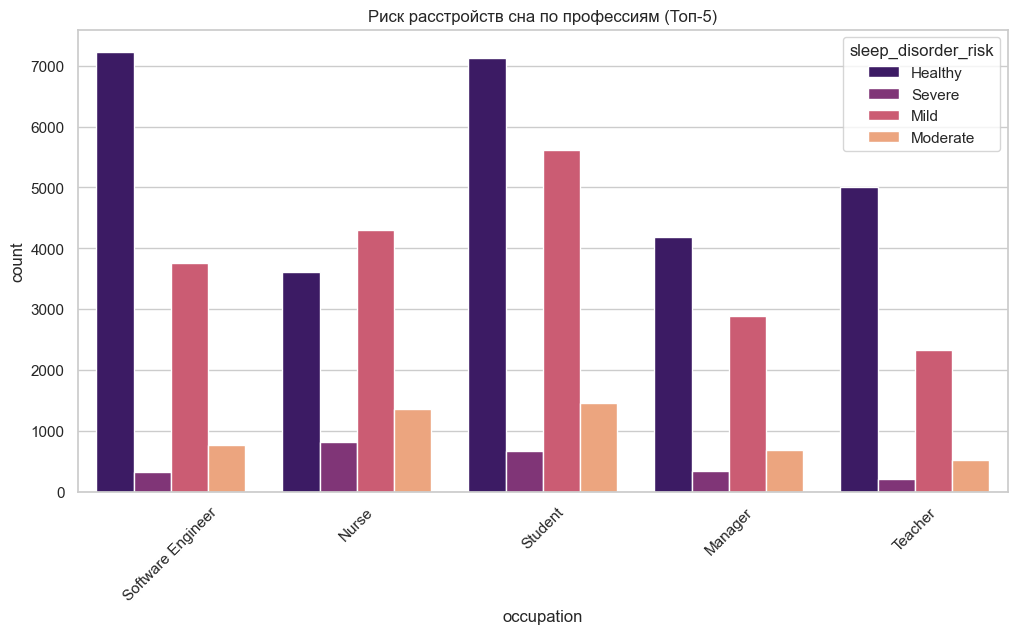

In [ ]:
# Рассмотрим некоторые возможные взаимосвязи

# Взаимосвязь уровня стресса и риска нарушения
if 'stress_score' in df_processed.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_processed, x=target_col, y='stress_score', palette='Set2', hue=target_col)
    plt.title('Уровень стресса в разрезе нарушения сна')
    plt.show()

# Взаимосвязь профессии и риска нарушения
if 'occupation' in df_processed.columns:
    plt.figure(figsize=(12, 6))
    top_jobs = df_processed['occupation'].value_counts().head(5).index
    sns.countplot(data=df_processed[df_processed['occupation'].isin(top_jobs)], 
                  x='occupation', hue=target_col, palette='magma')
    plt.title('Риск нарушений сна по профессиям (Топ-5)')
    plt.xticks(rotation=45)
    plt.show()

### 5. Корректный сплит (Train / Val / Test)
Чтобы избежать Data Leakage, проводим разбиение ДО любого кодирования (OneHot) и стандартизации (StandardScaler).

Используем параметр `stratify`, чтобы во всех трех выборках сохранить одинаковые пропорции классов.

In [18]:
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

# Шаг 1: 70% на Train, 30% на временный сет (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Шаг 2: Временный сет бьем пополам -> 15% Validation, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Размер Train: {X_train.shape[0]} строк")
print(f"Размер Val:   {X_val.shape[0]} строк")
print(f"Размер Test:  {X_test.shape[0]} строк")

# Сохраняем в папку data/processed/ для следующего этапа (моделирования)
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_val.to_csv('../data/processed/X_val.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_val.to_csv('../data/processed/y_val.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

Размер Train: 70000 строк
Размер Val:   15000 строк
Размер Test:  15000 строк
